In [97]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer

## Part 1: Retrieve the Data

In [ ]:
data = load_breast_cancer()

To preprocess the data, we converted the breast cancer data into a **Pandas dataframe**, with `data` as the cell values and `feature_names` as the column names. In addition, the `target` values were added as an additional column. 

In [108]:
data_df = pd.DataFrame(data.data, columns=data.feature_names)
data_df['target'] = data.target
data_df

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,0.1726,0.05623,...,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115,0
565,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,0.1752,0.05533,...,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637,0
566,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,0.1590,0.05648,...,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820,0
567,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,0.2397,0.07016,...,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400,0


**How many features are there?** 

*To calculate this, we extract the number of columns of the dataset using `.shape`, and minus 1 to not include the target column.*

In [109]:
print("Number of features:", data_df.shape[1]-1)

Number of features: 30


**What do the features represent?**

*To figure this out, we looked up documentation for the Wisconsin breast cancer dataset.*

In [ ]:
print("The features represent characteristics of cell nuclei of breast cancer masses")

**What are the different classes in the the target variable?**

*To figure this out, we looked at the `target_names` variable in the original data. Malignant is encoded as 0 and benign is encoded as 1 in the `target` column.*

In [7]:
bc_targets = np.array(data.target_names)
print("The different classes in the target variable are:", bc_targets)

The different classes in the target variable are: ['malignant' 'benign']


**How many samples are in the dataset?**

*To calculate this, we extract the number of rows of the dataset using `.shape`.*

In [40]:
print("Number of samples:", data_df.shape[0])

Number of samples: 569


## Part 2: Prepare the Data

In [45]:
from sklearn.model_selection import train_test_split

We set `X` and `y` variables in preparation for linear classification. `X` is our independent variables, the features, and `y` is our dependent variable, the target class.

In [46]:
X = data_df.drop(columns=['target'])
y = data_df['target']

Then, we split `X` and `y` into training and test datasets. `X_train`, `X_test`, `y_train`, and `y_test` represent a splitting of the `X` and `y` data, The `0.3` specifies that we want 30% of the data to be used for test data and 70& to be used for training. `stratify` instructs sklearn to split the data in a way that preserves the frequency of occurence of different target classes. Finally, we specify `random_state` to control the randomization for reproducibility. 

In [110]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, stratify=y, random_state=1)

**What proportion of the data is in the training set?**

70% of the data is in the training set.

**Why was that proportion chosen?**

We train the model using 'most' of the data and hold back a small amount to use as validation. For a small dataset like the one we're working with, a 70/30 split provides the model enough data for a statistically significant evaluation. 

## Part 3: Fit a Linear Classifier

In [89]:
from sklearn.linear_model import SGDClassifier

Now we are ready to train our model. We'll use the `SGDClassifier` ("Stochastic Gradient Descent" -- models based on an associated family of Gradient Descent algorithms) class from the `sklearn.linear_model` model. We instantiate the SGDClassifier object first, specifying `loss="perceptron"` to use the Perceptron algorithm. Then we can perform the model training using the `fit` function. Now the `clf` object is the trained model that can be used to predict target class of tumor samples using `clf.predict()`. 

In [90]:
clf = SGDClassifier(loss="perceptron", alpha=0.1)
clf.fit(X_train, y_train)

This algorithm is designed to work with data represented as an array of floating point values for the features
The breast cancer dataset fits this description because the samples contain decimal numbers to describe each tumor characteristic


**According to the documentation, what sort of data is this algorithm designed to work with?**

This algorithm is designed to work with data represented as an array of floating point values for the features.

**Does the breast cancer dataset fit that description?**

The breast cancer dataset fits this description because the samples contain decimal numbers to describe each tumor characteristic.

## Part 4: Validation and Assessment

In [91]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import ConfusionMatrixDisplay

Now we validation using `accuracy_score` from the `sklearn.metrics` module -- compute the accuracy of our model against the test dataset, as well as the training data to see how they compare. The `accuracy_score` function takes 2 parameters: the dependent variable and the predictions on the independent variables. 

In [92]:
accuracy_test = accuracy_score(y_test, clf.predict(X_test))
accuracy_train = accuracy_score(y_train, clf.predict(X_train))

The result is a float from 0 to 1 containing the fraction of correctly classified samples.

In [93]:
accuracy_train

0.914572864321608

In [94]:
accuracy_test

0.9181286549707602

We can visualize the results using a confusion matrix, which compares the predicted label of a model against the actual label for all values in the target class. Here, we use the `ConfusionMatrixDisplay.from_estimator()` function to plot it.

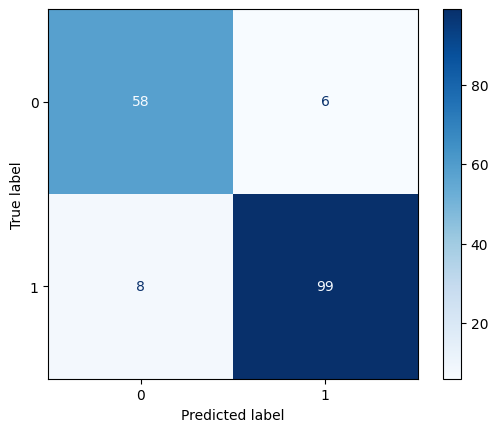

In [98]:
cm_display = ConfusionMatrixDisplay.from_estimator(clf, X_test, y_test, cmap=plt.cm.Blues, normalize=None)

**How does the model perform with respect to different labels in the target class?**

The model is performs slightly better with class 1 (benign), but both are about equal with about 90% precision.

**Do you think one is more important to minimize?**

6 cases were predicted to be benign but were actually malignant (false negatives). In the context of breast cancer diagnosis, minimizing false negatives is more important to avoid missing diagnoses -- having more false alarms is safer. 